# 1. Import CellRefiner and packages

In [ ]:
import numpy as np
import squidpy as sq
import seaborn as sns
from matplotlib import pyplot as plt
import scanpy as sc
import cellrefiner as cr

# 2. Load Data

The source data of seqFISH+ mouse cortex can be found at https://github.com/CaiGroup/seqFISH-PLUS.

Citation: Eng, C.L. et al. Transcriptome-scale super-resolved imaging in tissues by RNA seqFISH+. Nature 568, 235-239 (2019).

The preproceed dataset `seqFISH_plus_cortex.h5ad` can be download from [dropbox](https://www.dropbox.com/scl/fo/p8clpuy8q2eabofxj0mll/AM9nZvS39lE8LyVhCh5rD-4?rlkey=d57pfxykfneuwfdqlhnutsaox&st=so6keqcl&dl=0)

In [ ]:
adata_sc = sc.read_h5ad('data/seqFISH_plus_cortex.h5ad')
# preprocessing
sc.pp.filter_cells(adata_sc,min_genes=3)
sc.pp.filter_genes(adata_sc,min_cells=3)
sc.pp.normalize_total(adata_sc)
sc.pp.log1p(adata_sc)
cluster_key_sc = 'cell_type1'

group_counts = adata_sc.obs[cluster_key_sc].value_counts()
one_cell_group = group_counts[group_counts == 1].index.tolist()
I = ~adata_sc.obs[cluster_key_sc].isin(one_cell_group)
adata_sc = adata_sc[I].copy() # remove cell groups which only have one cell
print(adata_sc)

AnnData object with n_obs × n_vars = 521 × 10000
    obs: 'Field_of_View', 'Region', 'Cell_ID', 'louvain', 'cell_type', 'cell_type1', 'leiden', 'n_genes'
    var: 'n_cells'
    uns: 'Region_colors', 'cell_type1_colors', 'cell_type_colors', 'leiden', 'louvain_colors', 'neighbors', 'pca', 'log1p'
    obsm: 'X_pca', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


Generate pseudo st data

In [4]:
xc=adata_sc.obsm['spatial']
gene_x=adata_sc.X.toarray()

x_range = [np.min(xc,axis=0)[0]+100,np.max(xc,axis=0)[0]-100]
y_range = [np.min(xc,axis=0)[1]+100,np.max(xc,axis=0)[1]-100]
Nx=35
Ny = int((Nx+1)/(x_range[1]-x_range[0])*(y_range[1]-y_range[0]))
x = np.linspace(*x_range, Nx)
y = np.linspace(*y_range, Ny)
# x = x[:-1]
# y = y[:-1]
xx, yy = np.meshgrid(x, y)
# select spots surrounded by cells
wx = (x_range[1]-x_range[0])/(Nx-1)
wy = (y_range[1]-y_range[0])/(Ny-1)
cell_xs_i = np.vstack( [(xc[:,0]-x[0]+wx/2)//wx, (xc[:,1]-y[0]+wy/2)//wy] ).T
have_cell = np.zeros_like(xx)
cell_in_spot_gt = [] # cells assigned to each spot
for i,yi in enumerate(y):
    for j,xj in enumerate(x):
        I = (xc[:,0]>=xj-wx/2)&(xc[:,0]<xj+wx/2)&(xc[:,1]>=yi-wy/2)&(xc[:,1]<yi+wy/2)
        have_cell[i,j] = np.any(I)
        if have_cell[i,j]:
            cell_in_spot_gt.append( np.where(I)[0] )
xxf = xx.flatten()
yyf = yy.flatten()
have_cellf = have_cell.flatten().astype(bool)
xsm=np.concatenate(([xxf[have_cellf]],[yyf[have_cellf]]),axis=0).T # coordinates of which spots are assigned cells 
cellnum_spot_gt = np.array([x.shape[0] for x in cell_in_spot_gt])# cell count in each spot

X_sc_mean=np.zeros((xsm.shape[0],gene_x.shape[1]))
for i in range(X_sc_mean.shape[0]):
    X_sc_mean[i,:]=np.sum(gene_x[cell_in_spot_gt[i],:],axis=0)

In [5]:
from anndata import AnnData
import pandas as pd

adata_st=AnnData(X_sc_mean,var=pd.DataFrame(index=adata_sc.var.index), obs=pd.DataFrame(index=list(np.arange(X_sc_mean.shape[0]))))
adata_st.var_names = adata_sc.var_names
adata_st.obsm['spatial']=xsm
adata_st.obs['total_counts'] = np.sum(adata_st.X, axis=1)

print(adata_st)

AnnData object with n_obs × n_vars = 127 × 10000
    obs: 'total_counts'
    obsm: 'spatial'


/home/kxy/miniconda3/envs/cr_39_1/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


# 3. Run cellrefiner cell to spot mapping and spatial refinement 

Load the ligand-receptor database sourced from CellChat

In [6]:
db_lr = cr.pp.ligand_receptor_database()
adata_cr = cr.pp.spatial_mapping(adata_st,adata_sc,db_lr,cluster_key_sc = 'cell_type1',n_cell=4,scale=wx/2)

/home/kxy/miniconda3/envs/cr_39_1/lib/python3.9/site-packages/numpy/linalg/_linalg.py:2371: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)


GPU acceleration available with CuPy
.obsm['spatial'] exist. Add refined spatial coordinates to .obsm['spatial_cr']


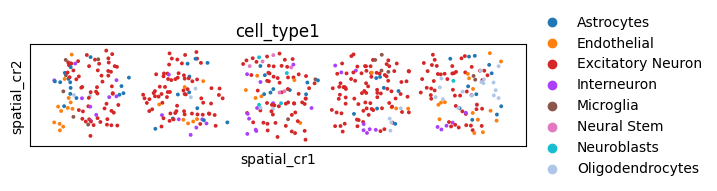

In [7]:
sc.pl.spatial(adata_cr,color = cluster_key_sc,basis='spatial_cr',spot_size=100)

# 4. cell shape modeling

In [8]:
sem = cr.tl.cell_shape_modeling(adata_cr,cluster_key = cluster_key_sc,spatial_key='spatial_cr',rd_ratio=3)

Simulation:   0%|          | 0/2000 [00:00<?, ?it/s]/home/kxy/miniconda3/envs/cr_39_1/lib/python3.9/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 27 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
Simulation: 100%|██████████| 2000/2000 [00:08<00:00, 242.21it/s]


add .obsp['contacts'], .uns['contacts']
Computing alpha-shape with parameters: alpha=None, ns=10, r=1.2


Processing Cell Shapes: 100%|██████████| 508/508 [00:04<00:00, 109.05it/s]


<Axes: >

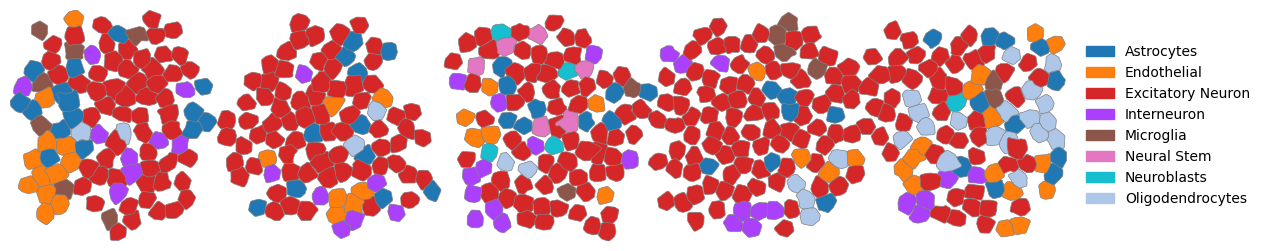

In [9]:
fig,ax=plt.subplots(figsize=(18,3))
cr.pl.plot_cell_shape(sem,ax=ax,boundary_color='gray',boundary_width=0.5)

# 5. Contact-based communication analysis

In [37]:
db_lr = cr.pp.ligand_receptor_database(signaling_types='Cell-Cell Contact')
db_lr = cr.pp.filter_lr_database(db_lr,adata_cr, min_cell_pct=0.01)
cr.tl.contact_communication(db_lr, adata = adata_cr)

add .uns['contact_signal_info']
add .obsm['sender_signal'], .obsm['receiver_signal']


<Axes: >

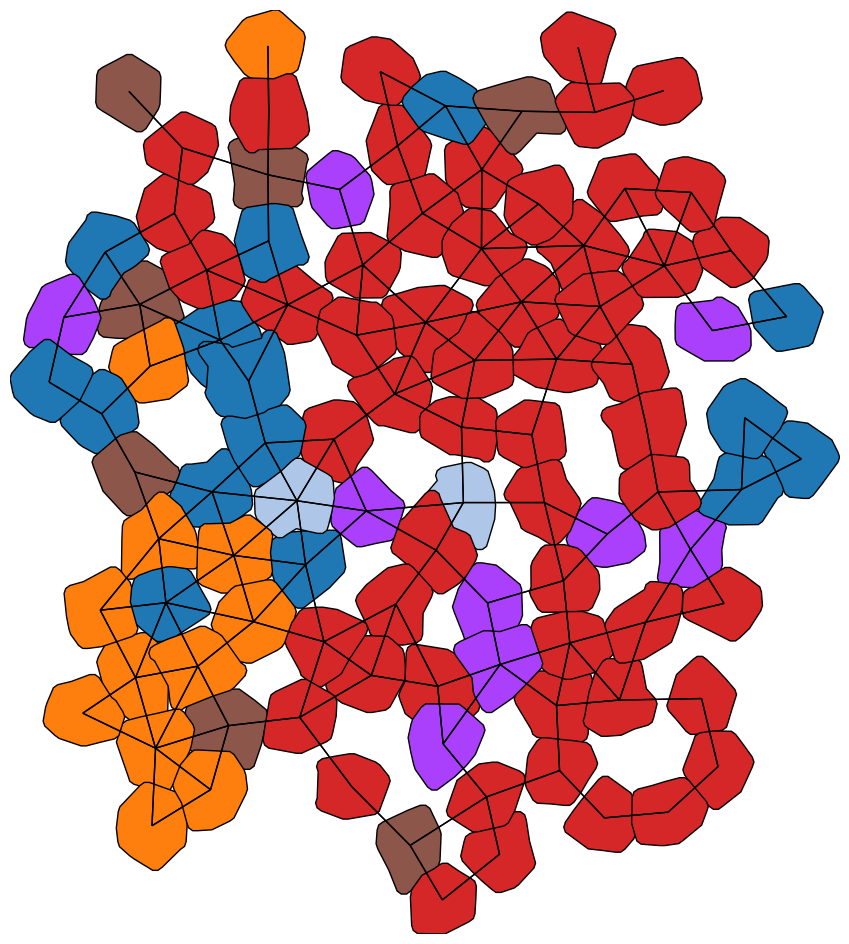

In [10]:
# select fov0
box_list = []
x = adata_cr.obsm['spatial_cr']
for fov in adata_sc.obs['Field_of_View'].unique():
    x_sc = adata_sc[adata_sc.obs['Field_of_View']==fov].obsm['spatial']
    box_list.append(np.hstack([x_sc.min(axis=0)-300,x_sc.max(axis=0)-x_sc.min(axis=0)+600]))

box = box_list[0]
clist = np.where( np.logical_and(x[:,0]>=box[0],x[:,0]<box[0]+box[2]) & np.logical_and(x[:,1]>=box[1],x[:,1]<box[1]+box[3]) )[0]

# visualize cell-cell contacts
fig, ax = plt.subplots(figsize=(12,12))
cr.pl.plot_cell_shape(sem,ax=ax,cid_list=clist,boundary_color='k',boundary_width=1,enable_legend=False)
cr.pl.plot_contact_signal(sem,ax=ax,cid_list = clist)

# visualize Cd22-Ptprc signal
# cr.pl.plot_contact_signal(sem,ax=ax,cid_list = clist,signal='Cd22-Ptprc') 

cluster communication

In [38]:
for signal in adata_cr.uns['contact_signal_info']['lr_pair']:
    cr.tl.cluster_communication(adata_cr,cluster_key_sc,signal=signal)